# 05 — Combined two-dataset multiclass scorer

Trains the same boundary-aware ordinal XGBoost model as notebook 04, but on
labels from **both** blinded-scoring runs at once:

| source | envelope features | scored labels |
|--------|-------------------|---------------|
| `old`  | `../data/all_envelope_rows_wide_combined_base.csv` | `CSVs-ALL-Opto-Flys/blinded_video_scores.csv` |
| `new`  | `CSVs-New-Opto-Flys/all_envelope_rows_wide_combined_base.csv` | `CSVs-New-Opto-Flys/blinded_video_scores.csv` |

Each source is loaded, filtered to its scoring-trace rows, and merged to its
labels on `(dataset, fly, fly_number, testing_N)`. The same **11 engineered + 13
signal features** are computed per source, then the feature tables are
concatenated. Odor onset is treated as **30 s** for both (per your setting).


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

## Config & data sources

In [2]:
PROJECT_ROOT = Path('..')
OUTPUT_DIR = PROJECT_ROOT / 'outputs/combined_two_datasets'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----- Core settings -----
SEED = 42
FPS = 40
ODOR_ON_SEC = 30          # onset used for both datasets (before/during/after split)
ODOR_OFF_SEC = 60
ODOR_ON_IDX = int(ODOR_ON_SEC * FPS)
ODOR_OFF_IDX = int(ODOR_OFF_SEC * FPS)

EXCLUDE_TRIAL_NUM_FROM_EVAL = 11   # testing_11 kept train-only, never in val/test
REMAP_6_TO_5 = True
SCORE_LEVELS = [-1, 0, 1, 2, 3, 4, 5]
LABEL_COL = 'user_score'

CLASS_WEIGHTS = {-1: 1.0, 0: 3.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}

ENGINEERED_FEATURES = [
    'AUC-During-Before-Ratio', 'AUC-After-Before-Ratio', 'global_max',
    'trimmed_global_min', 'local_min', 'local_max', 'local_min_before',
    'local_max_before', 'local_min_during', 'local_max_over_global_min',
    'local_max_during_over_global_min',
]
SIGNAL_FEATURES = [
    'mean_shift_z', 'std_ratio', 'peak_z', 'auc_ratio', 'total_power_ratio',
    'power_ratio_vlow', 'power_ratio_low', 'power_ratio_mid', 'power_ratio_high',
    'power_ratio_vhigh', 'frac_above_baseline', 'persistence', 'time_to_peak_frac',
]

# Old data uses the long distance-trace label; new data uses testing_N_odor.
DISTANCE_TRACE_REGEX = r'^testing_\d+_fly\d+_distances_fly\d+_angle_distance_rms_envelope(?:\.csv)?$'

# Old scoring-dataset names -> trace/folder names. New dataset names already match.
DATASET_MAP = {
    'opto_3-oct': '3OCT-Training', 'opto_ACV': 'ACV-Training', 'opto_AIR': 'AIR-Training',
    'Benz_control': 'Benz-Control', 'opto_benz_1': 'Benz-Training',
    'opto_benz_1-flagged': 'Benz-Training-flagged', 'EB_control': 'EB-Control',
    'opto_EB': 'EB-Training', 'opto_EB(6-training)': 'EB-Training(No-Operant)',
    'opto_EB-flagged': 'EB-Training-flagged', 'hex_control': 'Hex-Control',
    'hex_control-flagged': 'Hex-Control-flagged', 'opto_hex': 'Hex-Training',
    'opto_hex-flagged': 'Hex-Training-flagged',
}

SOURCES = [
    {
        'name': 'old',
        'data': PROJECT_ROOT / 'data/all_envelope_rows_wide_combined_base.csv',
        'labels': Path('/home/ramanlab/Documents/cole/Data/CSVs-ALL-Opto-Flys/blinded_video_scores.csv'),
        'trace_regex': DISTANCE_TRACE_REGEX,   # keep only distance-trace rows
        'dataset_map': DATASET_MAP,
    },
    {
        'name': 'new',
        'data': Path('/home/ramanlab/Documents/cole/Data/CSVs-New-Opto-Flys/all_envelope_rows_wide_combined_base.csv'),
        'labels': Path('/home/ramanlab/Documents/cole/Data/CSVs-New-Opto-Flys/blinded_video_scores.csv'),
        'trace_regex': None,                   # keep any testing_N row
        'dataset_map': {},
    },
]

print('Odor window:', ODOR_ON_SEC, '->', ODOR_OFF_SEC, 's  (idx', ODOR_ON_IDX, '..', ODOR_OFF_IDX, ')')
for s in SOURCES:
    print(f"  source {s['name']:>3}: data={s['data']}  labels={s['labels']}")

Odor window: 30 -> 60 s  (idx 1200 .. 2400 )
  source old: data=../data/all_envelope_rows_wide_combined_base.csv  labels=/home/ramanlab/Documents/cole/Data/CSVs-ALL-Opto-Flys/blinded_video_scores.csv
  source new: data=/home/ramanlab/Documents/cole/Data/CSVs-New-Opto-Flys/all_envelope_rows_wide_combined_base.csv  labels=/home/ramanlab/Documents/cole/Data/CSVs-New-Opto-Flys/blinded_video_scores.csv


## Loaders, merge & feature extraction

`.csv`/`.parquet` auto-detected. Each source is merged on the core `testing_N` key.

In [3]:
def read_table(p):
    p = Path(p)
    return pd.read_parquet(p) if p.suffix.lower() == '.parquet' else pd.read_csv(p)

def interpolate_nans(trace):
    x = np.asarray(trace, dtype=float).copy()
    nans = np.isnan(x)
    if not nans.any():
        return x
    if nans.all():
        return np.zeros_like(x)
    idx = np.arange(len(x))
    x[nans] = np.interp(idx[nans], idx[~nans], x[~nans])
    return x

def band_power(psd, freqs, fmin, fmax):
    m = (freqs >= fmin) & (freqs < fmax)
    return float(np.sum(psd[m])) if np.any(m) else 0.0

def compute_signal_features(trace, fps=40):
    tr = interpolate_nans(trace)
    before = tr[:ODOR_ON_IDX]; during = tr[ODOR_ON_IDX:ODOR_OFF_IDX]; after = tr[ODOR_OFF_IDX:]
    eps = 1e-10
    b_mean, b_std = np.mean(before), np.std(before)
    d_mean, d_std = np.mean(during), np.std(during)
    a_mean = np.mean(after)
    auc_before = np.trapz(before) / max(len(before), 1)
    auc_during = np.trapz(during) / max(len(during), 1)
    f_b, pxx_b = signal.welch(before - b_mean, fs=fps, nperseg=min(256, len(before)), noverlap=min(128, max(len(before)//2, 1)))
    f_d, pxx_d = signal.welch(during - d_mean, fs=fps, nperseg=min(256, len(during)), noverlap=min(128, max(len(during)//2, 1)))
    bands = {'vlow': (0.0, 0.5), 'low': (0.5, 1.0), 'mid': (1.0, 3.0), 'high': (3.0, 5.0), 'vhigh': (5.0, 10.0)}
    out = {}
    out['mean_shift_z'] = float((d_mean - b_mean) / (b_std + eps))
    out['std_ratio'] = float(d_std / (b_std + eps))
    out['peak_z'] = float((np.max(during) - b_mean) / (b_std + eps))
    out['auc_ratio'] = float(auc_during / (auc_before + eps))
    bt = dt = 0.0
    for bn, (fmin, fmax) in bands.items():
        pb = band_power(pxx_b, f_b, fmin, fmax); pdw = band_power(pxx_d, f_d, fmin, fmax)
        out[f'power_ratio_{bn}'] = float(pdw / (pb + eps)); bt += pb; dt += pdw
    out['total_power_ratio'] = float(dt / (bt + eps))
    out['frac_above_baseline'] = float(np.mean(during > (b_mean + 2.0 * b_std)))
    out['persistence'] = float((a_mean - b_mean) / ((d_mean - b_mean) + eps))
    out['time_to_peak_frac'] = float(np.argmax(during) / max(len(during), 1))
    return out

def build_source(src):
    """Load one source, filter to scoring-trace rows, merge labels on (dataset, fly, fly_number, testing_N)."""
    data = read_table(src['data'])
    lab = read_table(src['labels'])[['dataset', 'fly', 'fly_number', 'trial_label', LABEL_COL]].copy()
    lab[LABEL_COL] = pd.to_numeric(lab[LABEL_COL], errors='coerce')
    if REMAP_6_TO_5:
        lab[LABEL_COL] = lab[LABEL_COL].replace(6, 5)
    lab = lab.dropna(subset=[LABEL_COL]).copy()
    lab[LABEL_COL] = lab[LABEL_COL].astype(int)

    regex = src['trace_regex'] or r'testing_\d+'
    data = data[data['trial_label'].astype(str).str.match(regex, na=False)].copy()

    dm = src['dataset_map']
    def norm(df):
        for c in ['dataset', 'fly', 'trial_label']:
            df[c] = df[c].astype(str).str.strip()
        df['core'] = df['trial_label'].str.extract(r'(testing_\d+)', expand=False)
        df['ds'] = df['dataset'].map(dm).fillna(df['dataset'])
        df['fly_number'] = pd.to_numeric(df['fly_number'], errors='coerce')
        return df
    data = norm(data); lab = norm(lab)
    keys = ['ds', 'fly', 'fly_number', 'core']
    merged = data.merge(lab[keys + [LABEL_COL]].drop_duplicates(keys), on=keys, how='inner')
    print(f"  [{src['name']}] trace rows={len(data):,}  labels={len(lab):,}  ->  merged={len(merged):,}")
    return merged

def source_features(merged):
    dir_cols = sorted([c for c in merged.columns if c.startswith('dir_val_')], key=lambda x: int(x.split('_')[-1]))
    sig = pd.DataFrame([compute_signal_features(merged.iloc[i][dir_cols].values.astype(float), FPS) for i in range(len(merged))]).reset_index(drop=True)
    Xe = merged[ENGINEERED_FEATURES].reset_index(drop=True)
    Xs = sig[SIGNAL_FEATURES].reset_index(drop=True)
    return Xe, Xs

## Build combined feature matrix

In [4]:
Xe_list, Xs_list, y_list, meta_list = [], [], [], []
for s in SOURCES:
    merged = build_source(s)
    Xe, Xs = source_features(merged)
    Xe_list.append(Xe); Xs_list.append(Xs)
    y_list.append(merged[LABEL_COL].reset_index(drop=True))
    meta = merged[['dataset', 'fly', 'fly_number', 'trial_label']].reset_index(drop=True).copy()
    meta['source'] = s['name']
    meta['trial_num'] = pd.to_numeric(
        meta['trial_label'].astype(str).str.extract(r'testing_(\d+)')[0], errors='coerce'
    ).fillna(-1).astype(int)
    meta_list.append(meta)
    del merged

X_engineered = pd.concat(Xe_list, ignore_index=True)
X_signal = pd.concat(Xs_list, ignore_index=True)
X_combined = pd.concat([X_engineered, X_signal], axis=1)
y = pd.concat(y_list, ignore_index=True).astype(int)
meta = pd.concat(meta_list, ignore_index=True)

for X in [X_engineered, X_signal, X_combined]:
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(numeric_only=True), inplace=True)

print('\nCombined matrices:')
print('  Engineered:', X_engineered.shape)
print('  Signal:    ', X_signal.shape)
print('  Combined:  ', X_combined.shape)
print('\nRows per source:'); print(meta['source'].value_counts())
print('\nLabel distribution (combined):'); print(y.value_counts().sort_index())
print('\nLabel distribution by source:')
print(pd.crosstab(meta['source'], y))

  [old] trace rows=4,120  labels=736  ->  merged=735
  [new] trace rows=2,602  labels=296  ->  merged=284

Combined matrices:
  Engineered: (1019, 11)
  Signal:     (1019, 13)
  Combined:   (1019, 24)

Rows per source:
source
old    735
new    284
Name: count, dtype: int64

Label distribution (combined):
user_score
-1     86
 0    490
 1     57
 2     86
 3     89
 4    108
 5    103
Name: count, dtype: int64

Label distribution by source:
user_score  -1    0   1   2   3   4   5
source                                 
new         15  156  34  29  23  20   7
old         71  334  23  57  66  88  96


## Boundary-aware ordinal loss

Same penalty matrix and custom expected-cost objective as notebook 04 (critical `1↔2` boundary).

In [5]:
ORIGINAL_CLASSES = np.array([-1, 0, 1, 2, 3, 4, 5])
N_CLASSES = len(ORIGINAL_CLASSES)
ORIGINAL_TO_XGBOOST = {orig: idx for idx, orig in enumerate(ORIGINAL_CLASSES)}
XGBOOST_TO_ORIGINAL = {idx: orig for idx, orig in enumerate(ORIGINAL_CLASSES)}

def class_to_idx(c):
    return int(np.where(ORIGINAL_CLASSES == c)[0][0])

PENALTY_MATRIX = np.zeros((N_CLASSES, N_CLASSES), dtype=np.float64)
specified_pairs = {(5, 4): 0.5, (4, 3): 0.5, (2, 3): 1.0, (2, 1): 5.0, (0, 1): 1.0,
                   (-1, 0): 1.0, (5, 3): 2.0, (-1, 1): 2.0, (3, 1): 10.0}
for (c1, c2), penalty in specified_pairs.items():
    i, j = class_to_idx(c1), class_to_idx(c2)
    PENALTY_MATRIX[i, j] = penalty; PENALTY_MATRIX[j, i] = penalty
for i in range(N_CLASSES):
    for j in range(i + 1, N_CLASSES):
        if PENALTY_MATRIX[i, j] == 0:
            distance = abs(ORIGINAL_CLASSES[i] - ORIGINAL_CLASSES[j])
            PENALTY_MATRIX[i, j] = PENALTY_MATRIX[j, i] = {1: 1.0, 2: 2.0, 3: 3.0, 4: 4.0, 5: 6.0, 6: 8.0}[distance]

print('Penalty matrix:')
print(pd.DataFrame(PENALTY_MATRIX, index=ORIGINAL_CLASSES, columns=ORIGINAL_CLASSES))
print(f"\nCritical 1<->2 penalty: {PENALTY_MATRIX[class_to_idx(1), class_to_idx(2)]:.1f}")

def custom_ordinal_objective(preds, dtrain):
    labels = dtrain.get_label().astype(int)
    n = len(labels)
    pr = preds.reshape(n, N_CLASSES)
    ex = np.exp(pr - np.max(pr, axis=1, keepdims=True))
    probs = ex / np.sum(ex, axis=1, keepdims=True)
    grad = np.zeros_like(pr); hess = np.zeros_like(pr)
    for i in range(n):
        p = probs[i]; cost = PENALTY_MATRIX[labels[i], :]
        grad[i, :] = p * (cost - np.dot(p, cost))
        hess[i, :] = p * (1.0 - p) + 1e-6
    return grad.flatten(), hess.flatten()

print('\nCustom objective ready.')

Penalty matrix:
     -1    0     1    2     3    4    5
-1  0.0  1.0   2.0  3.0   4.0  6.0  8.0
 0  1.0  0.0   1.0  2.0   3.0  4.0  6.0
 1  2.0  1.0   0.0  5.0  10.0  3.0  4.0
 2  3.0  2.0   5.0  0.0   1.0  2.0  3.0
 3  4.0  3.0  10.0  1.0   0.0  0.5  2.0
 4  6.0  4.0   3.0  2.0   0.5  0.0  0.5
 5  8.0  6.0   4.0  3.0   2.0  0.5  0.0

Critical 1<->2 penalty: 5.0

Custom objective ready.


## Split (testing_11 train-only) and train

In [6]:
idx = np.arange(len(y))
trial_num = meta['trial_num'].values

eval_allowed_mask = trial_num != EXCLUDE_TRIAL_NUM_FROM_EVAL
eval_allowed_idx = idx[eval_allowed_mask]
if len(eval_allowed_idx) < 20:
    raise ValueError('Too few rows for val/test after excluding testing_11.')

try:
    eval_pool_idx, test_idx = train_test_split(eval_allowed_idx, test_size=0.10, random_state=SEED, stratify=y.iloc[eval_allowed_idx])
    train_non_holdout_idx, val_idx = train_test_split(eval_pool_idx, test_size=0.1111111111, random_state=SEED, stratify=y.iloc[eval_pool_idx])
except ValueError:
    print('Stratified split failed (rare class); falling back to unstratified.')
    eval_pool_idx, test_idx = train_test_split(eval_allowed_idx, test_size=0.10, random_state=SEED, stratify=None)
    train_non_holdout_idx, val_idx = train_test_split(eval_pool_idx, test_size=0.1111111111, random_state=SEED, stratify=None)

holdout_idx = idx[~eval_allowed_mask]
train_idx = np.concatenate([train_non_holdout_idx, holdout_idx])

y_train_xgb = y.iloc[train_idx].map(ORIGINAL_TO_XGBOOST).values
y_val_xgb = y.iloc[val_idx].map(ORIGINAL_TO_XGBOOST).values
y_test_xgb = y.iloc[test_idx].map(ORIGINAL_TO_XGBOOST).values
y_train, y_val, y_test = y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx]

print(f'Train: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}')
print('Test rows per source:'); print(meta.iloc[test_idx]['source'].value_counts())

def fit_xgb_custom(X):
    dtrain = xgb.DMatrix(X.iloc[train_idx], label=y_train_xgb)
    dval = xgb.DMatrix(X.iloc[val_idx], label=y_val_xgb)
    params = {'num_class': N_CLASSES, 'tree_method': 'hist', 'max_depth': 3,
              'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0,
              'seed': SEED, 'disable_default_eval_metric': 1}
    return xgb.train(params, dtrain, num_boost_round=300, obj=custom_ordinal_objective,
                     evals=[(dval, 'validation')], verbose_eval=100)

models = {
    'engineered_only_xgb': fit_xgb_custom(X_engineered),
    'signal_only_xgb': fit_xgb_custom(X_signal),
    'combined_xgb': fit_xgb_custom(X_combined),
}

def evaluate_model(name, model, X):
    dval = xgb.DMatrix(X.iloc[val_idx])
    pv = np.argmax(model.predict(dval, output_margin=True).reshape(-1, N_CLASSES), axis=1)
    pred_val = np.array([XGBOOST_TO_ORIGINAL[i] for i in pv])
    dtest = xgb.DMatrix(X.iloc[test_idx])
    pt = np.argmax(model.predict(dtest, output_margin=True).reshape(-1, N_CLASSES), axis=1)
    pred_test = np.array([XGBOOST_TO_ORIGINAL[i] for i in pt])
    return {'model': name, 'val_accuracy': accuracy_score(y_val, pred_val),
            'val_macro_f1': f1_score(y_val, pred_val, average='macro'),
            'test_accuracy': accuracy_score(y_test, pred_test),
            'test_macro_f1': f1_score(y_test, pred_test, average='macro'),
            'test_within_1': np.mean(np.abs(pred_test - y_test.values) <= 1), 'pred': pred_test}

results = [evaluate_model(n, models[n], X) for n, X in
           [('engineered_only_xgb', X_engineered), ('signal_only_xgb', X_signal), ('combined_xgb', X_combined)]]
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pred'} for r in results]).sort_values('test_macro_f1', ascending=False)
display(results_df.round(4))

Train: 815  Val: 102  Test: 102
Test rows per source:
source
old    77
new    25
Name: count, dtype: int64


,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_within_1
2,combined_xgb,0.6471,0.4449,0.7353,0.5460,0.9412
0,engineered_only_xgb,0.6471,0.3902,0.6961,0.4255,0.9216
1,signal_only_xgb,0.6078,0.3843,0.6569,0.4179,0.9020


## Metrics & boundary-aware evaluation of the best model

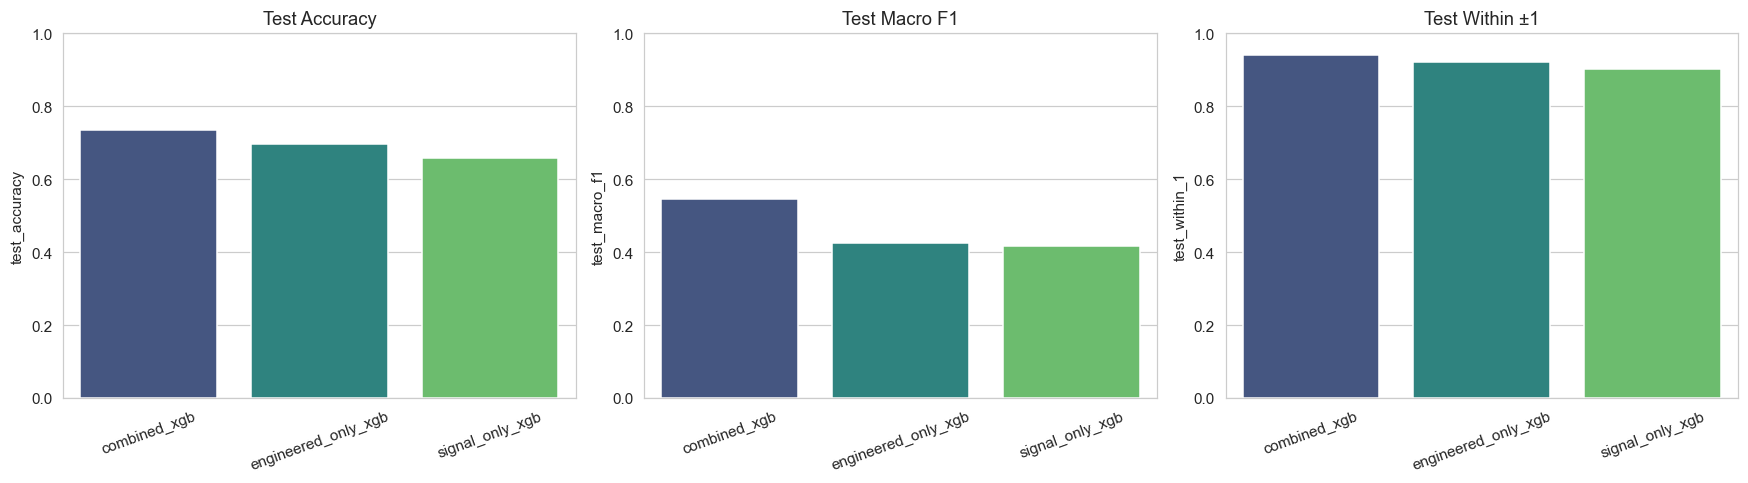

Best model: combined_xgb
Exact accuracy:  0.7353
Within ±1:       0.9412
MAE:             0.3627
Boundary-crossing error rate: 0.0686

Classification report:
              precision    recall  f1-score   support

          -1       0.75      0.67      0.71         9
           0       0.78      0.94      0.85        49
           1       0.00      0.00      0.00         6
           2       0.50      0.12      0.20         8
           3       0.56      0.56      0.56         9
           4       0.61      1.00      0.76        11
           5       1.00      0.60      0.75        10

    accuracy                           0.74       102
   macro avg       0.60      0.56      0.55       102
weighted avg       0.69      0.74      0.69       102



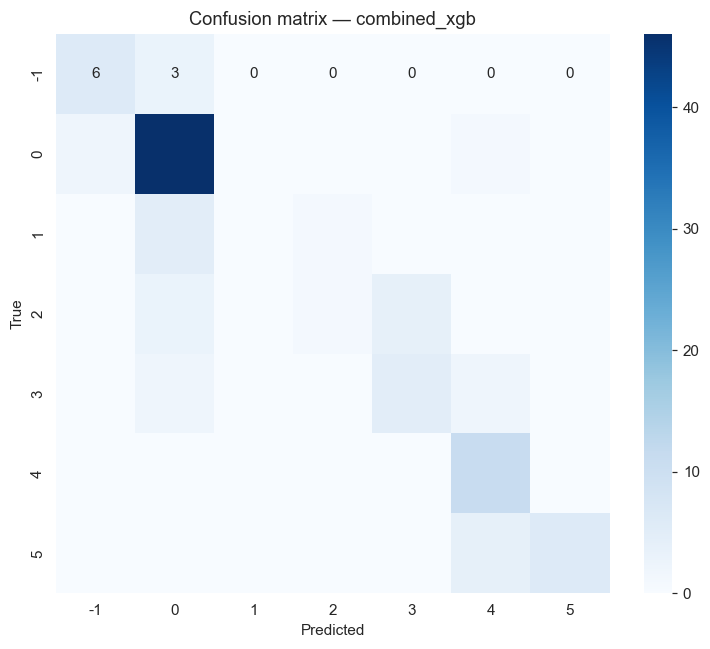

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, m, t in zip(axes, ['test_accuracy', 'test_macro_f1', 'test_within_1'],
                    ['Test Accuracy', 'Test Macro F1', 'Test Within ±1']):
    sns.barplot(data=results_df, x='model', y=m, ax=ax, palette='viridis')
    ax.set_title(t); ax.set_xlabel(''); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

best_name = results_df.iloc[0]['model']
best_model = models[best_name]
best_pred = results[results_df.index[0]]['pred']
print(f'Best model: {best_name}')
print(f'Exact accuracy:  {accuracy_score(y_test, best_pred):.4f}')
print(f'Within ±1:       {np.mean(np.abs(best_pred - y_test.values) <= 1):.4f}')
print(f'MAE:             {np.mean(np.abs(best_pred - y_test.values)):.4f}')

# no-reaction (<=1) vs reaction (>=2) boundary
tn = (y_test.values <= 1); pn = (best_pred <= 1)
print(f'Boundary-crossing error rate: {np.mean(tn != pn):.4f}')
print('\nClassification report:')
print(classification_report(y_test, best_pred, labels=SCORE_LEVELS, zero_division=0))

cm = confusion_matrix(y_test, best_pred, labels=SCORE_LEVELS)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=SCORE_LEVELS, yticklabels=SCORE_LEVELS, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'Confusion matrix — {best_name}')
plt.tight_layout(); plt.show()

## Save model & metrics

In [8]:
results_path = OUTPUT_DIR / 'model_comparison_metrics.csv'
pred_path = OUTPUT_DIR / f'{best_name}_true_vs_pred.csv'
model_path = OUTPUT_DIR / 'model_combined_xgb.json'
fi_path = OUTPUT_DIR / f'{best_name}_feature_importance.csv'

results_df.to_csv(results_path, index=False)
pd.DataFrame({'true': y_test.values, 'pred': best_pred,
             'source': meta.iloc[test_idx]['source'].values}).to_csv(pred_path, index=False)

feat_names = list(X_combined.columns)
gain = best_model.get_score(importance_type='gain')
fi = pd.DataFrame({'feature': feat_names,
                   'gain': [gain.get(f, 0.0) for f in feat_names]}).sort_values('gain', ascending=False)
fi.to_csv(fi_path, index=False)

models['combined_xgb'].save_model(str(model_path))
print('Saved:')
for p in [results_path, pred_path, fi_path, model_path]:
    print(' -', p)
display(fi.head(15))

Saved:
 - ../outputs/combined_two_datasets/model_comparison_metrics.csv
 - ../outputs/combined_two_datasets/combined_xgb_true_vs_pred.csv
 - ../outputs/combined_two_datasets/combined_xgb_feature_importance.csv
 - ../outputs/combined_two_datasets/model_combined_xgb.json


,feature,gain
13,peak_z,34.081341
21,frac_above_baseline,3.986057
19,power_ratio_high,3.476450
5,local_max,3.068487
20,power_ratio_vhigh,2.623361
10,local_max_during_over_global_min,2.571523
11,mean_shift_z,2.083520
12,std_ratio,1.910319
15,total_power_ratio,1.552423
14,auc_ratio,1.552313
